## TSED (Tree Similarity of Edit Distance) metric
https://arxiv.org/pdf/2404.08817

https://github.com/Etamin/TSED

In [ ]:
pip install tree-sitter-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.1/108.1 kB 6.9 MB/s eta 0:00:00


In [ ]:
pip install apted

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.3 MB/s eta 0:00:00


In [ ]:
pip install tree-sitter-language-pack

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.4/635.4 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.8/402.8 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 6.8 MB/s eta 0:00:00


In [ ]:
# https://arxiv.org/pdf/2404.08817
# https://github.com/Etamin/TSED
from apted import APTED, PerEditOperationConfig
from tree_sitter import Tree
from tree_sitter_language_pack import get_parser, SupportedLanguage


class Node:
    def __init__(self, name, path):
        self.id = path
        self.name = name
        self.children = []
        self.len_sexp = 0

    def add_child(self, node):
        self.children.append(node)


def parse_tree_string(tree_string):
    stack = []
    current_node = None
    tokens = tree_string.replace("(", " ( ").replace(")", " ) ").split()

    for token in tokens:
        if token == "(":
            if current_node is not None:
                stack.append(current_node)
            current_node = Node("", "")
        elif token == ")":
            if stack:
                parent_node = stack.pop()
                parent_node.add_child(current_node)
                current_node = parent_node
            else:
                # Extra closing parenthesis, ignore it
                continue
        else:
            # Use the content between brackets as the node name
            name = token.strip("()")
            if current_node is None:
                current_node = Node("", "")
            if name != "":
                # if ":" in name:
                #     name=name.split(":")[0]
                current_node.name = name
            else:
                current_node.name = " "

    return current_node


def _parse(language: SupportedLanguage, program_str: str, encoding="utf-8") -> Tree:
    """Returns a tree-sitter representation of a program string.

    Args:
        language (str): A programming language supported by
            tree_sitter_language_pack.
        program_str (str): A string representation of a program.
        encoding (str, optional): The encoding of program_str. Defaults to
            "utf-8".

    Returns:
        Tree: A tree-sitter representation of the given program string.
    """
    parser = get_parser(language)
    return parser.parse(bytes(program_str, encoding=encoding))


def _get_tree(language: SupportedLanguage, tree_str: str) -> Node:
    """Returns a Node (i.e., an AST) representation of the given string, which
    represents a program.

    Args:
        language (SupportedLanguage): A programming language supported by
            tree_sitter_language_pack.
        tree_str (str): A string representation of a program.

    Returns:
        Node: A Node representation of the given string.
    """
    tree_sitter_representation = _parse(language, tree_str)
    tree_sexp = str(tree_sitter_representation.root_node)
    tree_node = parse_tree_string(tree_sexp)
    tree_node.len_sexp = tree_sexp.count(")")
    return tree_node


def Calculate(
    programming_language: SupportedLanguage,
    origin: str,
    target: str,
    deletion_weight: float,
    insertion_weight: float,
    rename_weight: float,
) -> float:
    """Calculates the TSED (Tree Similarity of Edit Distance) score between two
    trees using the APTED algorithm
    (http://tree-edit-distance.dbresearch.uni-salzburg.at.

    Args:
        programming_language (SupportedLanguage): A programming language
            supported by tree_sitter_language_pack.
        origin (str): The origin string comprising a program.
        target (str): The destination string (i.e., the end-result after edit
            operations are applied) comprising a program.
        deletion_weight (float): The weight for deletion operations.
        insertion_weight (float): The weight for insertion operations.
        rename_weight (float): The weight for re-name operations.

    Returns:
        float: The TSED score computed for the two input trees.
    """
    tree1, tree2 = (
        _get_tree(programming_language, origin),
        _get_tree(programming_language, target),
    )
    max_len = max(tree1.len_sexp, tree2.len_sexp)
    apted = APTED(
        tree1,
        tree2,
        PerEditOperationConfig(deletion_weight, insertion_weight, rename_weight),
    )
    res = apted.compute_edit_distance()
    if max_len > 0:
        if res > max_len:
            return 0.0
        else:
            return (max_len - res) / max_len
    else:
        return 1.0

In [ ]:

line1 = "Code1"
line2 = "Code2"
ts_score = Calculate("python", line1, line2, 1.0, 0.8, 1.0)

In [ ]:
ts_score

1.0

In [ ]:
import os
# import torch
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pandas as pd



# Альтернативный способ через прямой парсинг event файлов
def find_all_text_tags_in_runs(runs_dir):
    """
    Находит все текстовые теги во всех экспериментах и сохраняет результаты сравнения в таблицу
    """
    results = []

    for experiment_name in os.listdir(runs_dir):
        experiment_path = os.path.join(runs_dir, experiment_name)

        if not os.path.isdir(experiment_path):
            continue

        event_files = [f for f in os.listdir(experiment_path) if f.startswith("events.out.tfevents")]

        if event_files:
            event_file_path = os.path.join(experiment_path, event_files[0])

            try:
                event_acc = EventAccumulator(event_file_path)
                event_acc.Reload()

                tags = event_acc.Tags()
                if 'tensors' in tags:
                    loss_tags = [tag for tag in tags['tensors'] if 'Loss_Function' in tag]
                    for tag in loss_tags:
                        tensor_events = event_acc.Tensors(tag)
                        if tensor_events:
                            # Декодируем tensor данные как текст
                            tensor_data = tensor_events[-1].tensor_proto.string_val[0]
                            loss_function_info = tensor_data.decode('utf-8')

                            loss_func_before, loss_func_after = extract_loss_functions_from_tensor(loss_function_info)

                            # Вычисляем метрику
                            calculate_result = Calculate("python", loss_func_before, loss_func_after, 1.0, 0.8, 1.0)

                            # Сохраняем результат
                            result_row = {
                                'experiment_name': experiment_name,
                                'calculate_result': calculate_result
                            }
                            results.append(result_row)

                            print("=" * 100)
                            print(f"Эксперимент: {experiment_name}")
                            print(f"Результат: {calculate_result}")
                            print("\n\n")

            except Exception as e:
                print(f"Ошибка в {experiment_name}: {e}")
                # Сохраняем информацию об ошибке
                error_row = {
                    'experiment_name': experiment_name,
                    'calculate_result': f"ERROR: {str(e)}"
                }
                results.append(error_row)

    # Создаем DataFrame и сохраняем в CSV
    if results:
        df = pd.DataFrame(results)

        # Сохраняем в CSV файл
        output_file = os.path.join(runs_dir, "comparison_results.csv")
        df.to_csv(output_file, index=False, encoding='utf-8')
        print(f"✅ Результаты сохранены в: {output_file}")

        # Выводим сводную таблицу
        print("\n📊 Сводная таблица результатов:")
        summary_df = df[['experiment_name', 'calculate_result']].copy()
        print(summary_df.to_string(index=False))

        return df
    else:
        print("❌ Не найдено данных для сравнения")
        return pd.DataFrame()



In [ ]:
import re

def extract_loss_functions_from_tensor(tensor_data):
    """
    Извлекает исходные функции потерь из сохраненного текста
    """
    # Декодируем если это tensor
    if hasattr(tensor_data, 'tensor_proto'):
        text_content = tensor_data.tensor_proto.string_val[0].decode('utf-8')
    else:
        text_content = tensor_data

    loss_func_before = None
    loss_func_after = None

    # Ищем исходную функцию потерь
    before_match = re.search(r'\*\*Исходная функция потерь:\*\*\s*```python\n(.*?)\n```', text_content, re.DOTALL)
    if before_match:
        loss_func_before = before_match.group(1).strip()

    # Ищем модифицированную функцию потерь
    after_match = re.search(r'\*\*Модифицированная функция потерь:\*\*\s*```python\n(.*?)\n```', text_content, re.DOTALL)
    if after_match:
        loss_func_after = after_match.group(1).strip()

    return remove_comments(loss_func_before), remove_comments(loss_func_after)


from codebleu import calc_codebleu

def remove_comments(code):
    """
    Удаляет комментарии из Python кода
    """
    # Удаляем блочные комментарии (тройные кавычки)
    code = re.sub(r'(\'\'\'[\s\S]*?\'\'\'|\"\"\"[\s\S]*?\"\"\")', '', code)

    # Удаляем однострочные комментарии
    code = re.sub(r'#.*$', '', code, flags=re.MULTILINE)

    # Удаляем пустые строки и лишние пробелы
    lines = code.split('\n')
    cleaned_lines = []
    for line in lines:
        stripped_line = line.strip()
        if stripped_line:  # Не добавляем пустые строки
            cleaned_lines.append(stripped_line)

    return '\n'.join(cleaned_lines)



In [ ]:
# Теперь используй путь к своим экспериментам
runs_dir = '/runs/Meta-Llama-3.1-8B-Instruct'  # путь
experiments_data = find_all_text_tags_in_runs(runs_dir)

Эксперимент: dinn_experiment_20251011_210205
Результат: 0.8610169491525423



Эксперимент: dinn_experiment_20251011_205652
Результат: 0.8695278969957081



Эксперимент: dinn_experiment_20251011_205152
Результат: 0.8964285714285714



Эксперимент: dinn_experiment_20251011_195025
Результат: 0.9428571428571428



Эксперимент: dinn_experiment_20251011_194351
Результат: 0.9878787878787878



Эксперимент: dinn_experiment_20251009_123821
Результат: 0.7886792452830191



Эксперимент: dinn_experiment_20251009_123313
Результат: 0.8195121951219513



Эксперимент: dinn_experiment_20251009_122815
Результат: 0.9222222222222222



Эксперимент: dinn_experiment_20251009_122301
Результат: 0.8713656387665197



Эксперимент: dinn_experiment_20251009_121752
Результат: 0.8290322580645162



Эксперимент: dinn_experiment_20251009_121228
Результат: 0.8782608695652174



Эксперимент: dinn_experiment_20251008_140151
Результат: 0.8638297872340426



Эксперимент: dinn_experiment_20251008_134607
Результат: 0.847302

In [ ]:
from codebleu import calc_codebleu


def calculate_codebleu_with_library(loss_func_before, loss_func_after):
    """
    Calculate CodeBLEU using the codebleu package
    Requires: pip install codebleu
    """
    result = calc_codebleu(
            references=[[loss_func_before]],  # reference code
            hypothesis=[loss_func_after],     # generated code
            lang="python",
            weights=(0.25, 0.25, 0.25, 0.25)  # alpha, beta, gamma, theta
        )

    return {
            'codebleu': result['codebleu'],
            'ngram_match_score': result['ngram_match_score'],
            'weighted_ngram_match_score': result['weighted_ngram_match_score'],
            'syntax_match_score': result['syntax_match_score'],
            'dataflow_match_score': result['dataflow_match_score']
        }

In [ ]:
import ast
import Levenshtein
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def calculate_code_similarity(original_func, modified_func):
    """
    Комплексное сравнение двух функций Python

    Returns:
        dict: Метрики схожести (0 =完全不同, 1 = идентичные)
    """

    def syntax_similarity(code1, code2):
        """Синтаксическое сходство через AST"""
        try:
            tree1 = ast.parse(code1)
            tree2 = ast.parse(code2)

            nodes1 = [type(n).__name__ for n in ast.walk(tree1)]
            nodes2 = [type(n).__name__ for n in ast.walk(tree2)]

            common = set(nodes1) & set(nodes2)
            return len(common) / max(len(set(nodes1)), len(set(nodes2)))
        except:
            return 0

    def structural_similarity(code1, code2):
        """Структурное сходство (Levenshtein + нормализация)"""
        # Нормализуем код: удаляем пробелы, приводим к нижнему регистру
        norm1 = ' '.join(code1.split()).lower()
        norm2 = ' '.join(code2.split()).lower()

        lev_dist = Levenshtein.distance(norm1, norm2)
        max_len = max(len(norm1), len(norm2))
        return 1 - lev_dist / max_len if max_len > 0 else 1

    def token_similarity(code1, code2):
        """Сходство токенов (упрощенный BLEU)"""
        tokens1 = code1.split()
        tokens2 = code2.split()

        if not tokens1 or not tokens2:
            return 0

        common_tokens = set(tokens1) & set(tokens2)
        return len(common_tokens) / max(len(set(tokens1)), len(set(tokens2)))

    def logic_preservation(code1, code2):
        """Сохранение логики (по ключевым элементам)"""
        try:
            tree1 = ast.parse(code1)
            tree2 = ast.parse(code2)

            key_elements1 = set()
            key_elements2 = set()

            for node in ast.walk(tree1):
                if isinstance(node, ast.FunctionDef):
                    key_elements1.add(f"func_{node.name}")
                elif isinstance(node, ast.Return):
                    key_elements1.add("return")
                elif isinstance(node, ast.Call):
                    if isinstance(node.func, ast.Name):
                        key_elements1.add(f"call_{node.func.id}")

            for node in ast.walk(tree2):
                if isinstance(node, ast.FunctionDef):
                    key_elements2.add(f"func_{node.name}")
                elif isinstance(node, ast.Return):
                    key_elements2.add("return")
                elif isinstance(node, ast.Call):
                    if isinstance(node.func, ast.Name):
                        key_elements2.add(f"call_{node.func.id}")

            common = key_elements1 & key_elements2
            return len(common) / max(len(key_elements1), len(key_elements2))
        except:
            return 0

    # Вычисляем все метрики
    syntax_sim = syntax_similarity(original_func, modified_func)
    struct_sim = structural_similarity(original_func, modified_func)
    token_sim = token_similarity(original_func, modified_func)
    logic_sim = logic_preservation(original_func, modified_func)

    # Комбинированный score (взвешенный)
    combined_score = (
        0.3 * syntax_sim +      # Структура кода
        0.3 * struct_sim +      # Текстовая схожесть
        0.2 * token_sim +       # Лексика
        0.2 * logic_sim         # Сохранение логики
    )

    return {
        'combined_similarity': combined_score,
        'syntax_similarity': syntax_sim,
        'structural_similarity': struct_sim,
        'token_similarity': token_sim,
        'logic_preservation': logic_sim
    }

def interpret_similarity(score):
    """Интерпретация результатов"""
    if score >= 0.9:
        return "Почти идентичные"
    elif score >= 0.7:
        return "Незначительные изменения"
    elif score >= 0.5:
        return "Умеренные изменения"
    elif score >= 0.3:
        return "Значительные изменения"
    else:
        return "Полная переработка"

# Пример использования
original = """
def loss_function(pred, target):
    return torch.mean((pred - target) ** 2)
"""

modified = """
def custom_loss(prediction, target_value):
    return torch.mean(torch.square(prediction - target_value))
"""

result = calculate_code_similarity(original, modified)

print(f"🎯 Общая схожесть: {result['combined_similarity']:.3f}")
print(f"📊 Интерпретация: {interpret_similarity(result['combined_similarity'])}")
print("\n📈 Детали:")
print(f"  Синтаксис: {result['syntax_similarity']:.3f}")
print(f"  Структура: {result['structural_similarity']:.3f}")
print(f"  Токены: {result['token_similarity']:.3f}")
print(f"  Логика: {result['logic_preservation']:.3f}")

🎯 Общая схожесть: 0.575
📊 Интерпретация: Умеренные изменения

📈 Детали:
  Синтаксис: 0.846
  Структура: 0.515
  Токены: 0.333
  Логика: 0.500


In [ ]:
import pandas as pd

df = pd.read_csv("/content/comparison_results.csv",delimiter=";")

In [ ]:
df

,Llama-3.3-70B-Instruct,Meta-Llama-3.1-8B-Instruct,DeepSeek-V3.1
0,0.946411,0.861017,0.893333
1,0.932394,0.869528,0.905882
2,0.905882,0.896429,0.861017
3,0.899552,0.942857,0.896429
4,0.850000,0.987879,0.902703
5,0.909091,0.788679,0.878261
6,0.946411,0.819512,0.928972
7,0.928972,0.922222,0.899552
8,0.957282,0.871366,0.976119
9,0.872414,0.829032,0.983920


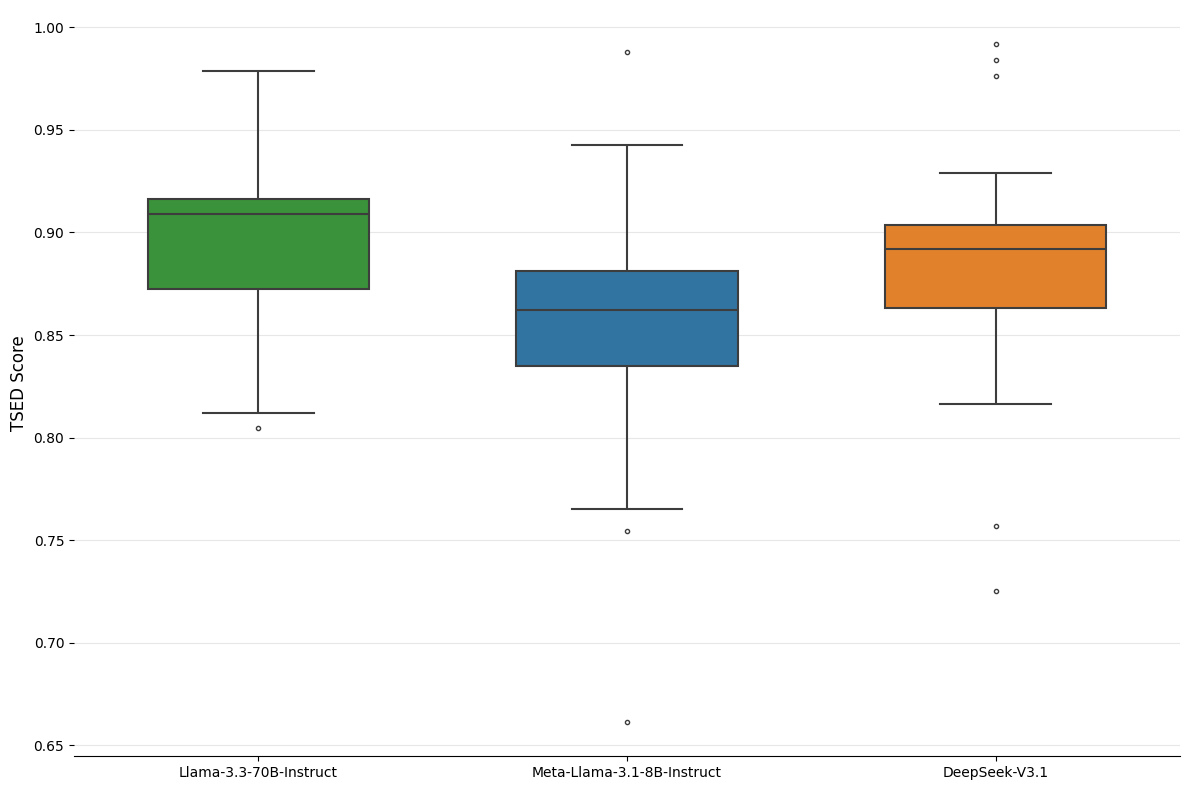

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Настройка стиля
plt.style.use('default')
sns.set_palette("husl")

# Создаем красивый boxplot
plt.figure(figsize=(12, 8))

# Boxplot с seaborn
sns.boxplot(data=df, width=0.6, fliersize=3, linewidth=1.5,palette=['#2ca02c', '#1f77b4', '#ff7f0e' ])

# Добавляем swarmplot для отображения всех точек
# sns.swarmplot(data=df, size=4, alpha=0.7, color=".25")

# Настройка оформления
# plt.title('Comparison TSED Score for LLMs', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('TSED Score', fontsize=12)
# plt.xlabel('LLMs', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
# Красивая рамка
sns.despine(left=True)

plt.tight_layout()
# plt.show()
plt.savefig("figure_4.pdf", bbox_inches='tight')

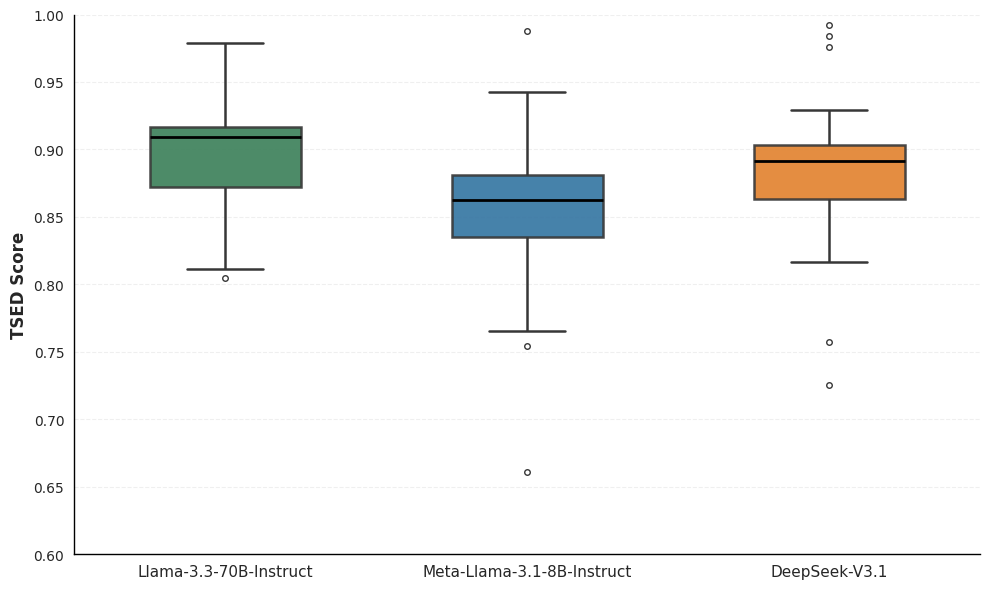

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Настройка стиля в стиле первого графика
plt.style.use('default')
sns.set_style("whitegrid")  # Более легкая сетка

# Создаем figure и axes как в первом графике
fig, ax = plt.subplots(figsize=(10, 6))

# Кастомная палитра (аналогично первому графику)
custom_palette = ['#2E8B57', '#1f77b4', '#FF7F0E']  # зеленый, синий, оранжевый

# Boxplot с улучшенными параметрами
sns.boxplot(data=df, width=0.5, fliersize=4, linewidth=1.8,
            palette=custom_palette, ax=ax,
            boxprops=dict(alpha=0.9),
            whiskerprops=dict(linewidth=1.8),
            capprops=dict(linewidth=1.8),
            medianprops=dict(color='black', linewidth=2))

# Добавляем swarmplot для отображения всех точек (раскомментируйте если нужно)
# sns.swarmplot(data=df, size=3, alpha=0.6, color=".2", ax=ax)

# Настройка оформления в стиле первого графика
ax.set_ylabel('TSED Score', fontsize=12, fontweight='bold')
# ax.set_xlabel('LLMs', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=11)

# Легкая сетка как в первом графике
ax.grid(axis='y', alpha=0.2, linestyle='--', linewidth=0.8)

# ДОБАВЛЯЕМ ЧЕРНЫЕ ОСИ
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)

# Убираем рамку
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Настройка осей
ax.set_ylim(0.6, 1)
ax.set_xlim(-0.5, 2.5)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Настройка пределов осей если нужно
# ax.set_ylim(0, 1)  # раскомментируйте и настройте под ваши данные

plt.tight_layout()

# Сохраняем в PDF
plt.savefig("figure_4.pdf", bbox_inches='tight')
plt.show()

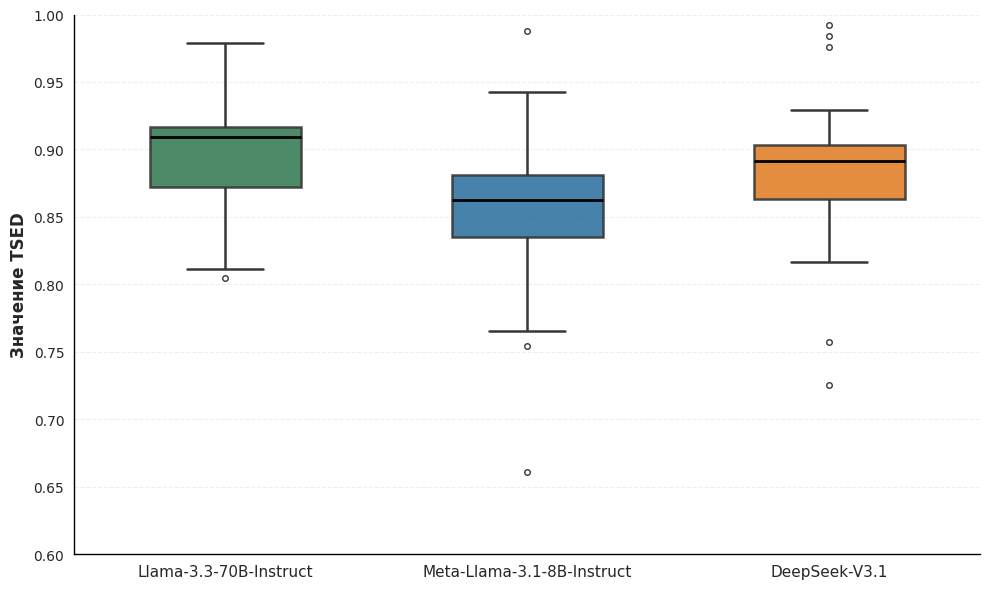

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Настройка стиля в стиле первого графика
plt.style.use('default')
sns.set_style("whitegrid")  # Более легкая сетка

# Создаем figure и axes как в первом графике
fig, ax = plt.subplots(figsize=(10, 6))

# Кастомная палитра (аналогично первому графику)
custom_palette = ['#2E8B57', '#1f77b4', '#FF7F0E']  # зеленый, синий, оранжевый

# Boxplot с улучшенными параметрами
sns.boxplot(data=df, width=0.5, fliersize=4, linewidth=1.8,
            palette=custom_palette, ax=ax,
            boxprops=dict(alpha=0.9),
            whiskerprops=dict(linewidth=1.8),
            capprops=dict(linewidth=1.8),
            medianprops=dict(color='black', linewidth=2))

# Добавляем swarmplot для отображения всех точек (раскомментируйте если нужно)
# sns.swarmplot(data=df, size=3, alpha=0.6, color=".2", ax=ax)

# Настройка оформления в стиле первого графика
ax.set_ylabel('Значение TSED', fontsize=12, fontweight='bold')
# ax.set_xlabel('LLMs', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=11)

# Легкая сетка как в первом графике
ax.grid(axis='y', alpha=0.2, linestyle='--', linewidth=0.8)

# ДОБАВЛЯЕМ ЧЕРНЫЕ ОСИ
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)

# Убираем рамку
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Настройка осей
ax.set_ylim(0.6, 1)
ax.set_xlim(-0.5, 2.5)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Настройка пределов осей если нужно
# ax.set_ylim(0, 1)  # раскомментируйте и настройте под ваши данные

plt.tight_layout()

# Сохраняем в PDF
plt.savefig("figure_4.pdf", bbox_inches='tight')
plt.show()

In [ ]:
plt.savefig("figure_4.pdf", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Nemenyi post-hoc test

In [ ]:
pip install scikit-posthocs

In [ ]:
from scipy import stats
import scikit_posthocs as sp
import numpy as np
import pandas as pd

# Данные из DataFrame
data_group1 = df['Meta-Llama-3.1-8B-Instruct'].values
data_group2 = df['Llama-3.3-70B-Instruct'].values
data_group3 = df['DeepSeek-V3.1'].values

# Тест Фридмана
stats.friedmanchisquare(data_group1, data_group2, data_group3)

# Тест Неменьи
data = np.array([data_group1, data_group2, data_group3])
nemenyi_result = sp.posthoc_nemenyi_friedman(data.T)
model_names = ['Meta-Llama-3.1-8B', 'Llama-3.3-70B', 'DeepSeek-V3.1']
nemenyi_result.index = model_names
nemenyi_result.columns = model_names

print(nemenyi_result.round(6))

                   Meta-Llama-3.1-8B  Llama-3.3-70B  DeepSeek-V3.1
Meta-Llama-3.1-8B           1.000000       0.007997       0.467564
Llama-3.3-70B               0.007997       1.000000       0.166759
DeepSeek-V3.1               0.467564       0.166759       1.000000
